# Monte Carlo Option Pricing for a European Call

## Objective
The purpose of this project is to price a European call option using Monte Carlo simulation and compare the result with the Black–Scholes analytical solution.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# Model parameters
S0 = 100      # initial stock price
K = 100       # strike price
r = 0.05      # risk-free rate
sigma = 0.2   # volatility
T = 1.0       # maturity in years
q = 0.02      # annual dividend rate

# Simulation parameters
n_steps = 252
n_paths = 10000

## Model Assumption

We assume the stock price follows Geometric Brownian Motion:


$dS_t = r S_t dt + \sigma S_t dW_t$


Under the risk-neutral measure, the discrete-time simulation formula is:


$S_{t+\Delta t} = S_t \exp\left((r - \frac{1}{2}\sigma^2)\Delta t + \sigma \sqrt{\Delta t} Z\right)$

where $(Z \sim N(0,1)$).

For a European call option, the payoff at maturity is:

$max(S_T - K, 0)$, where K is the strike price


The Monte Carlo price is the discounted expected payoff:


$C = e^{-rT} \mathbb{E}[\max(S_T - K, 0)]$

Text(0.5, 1.0, 'Geometric Brownian Motion')

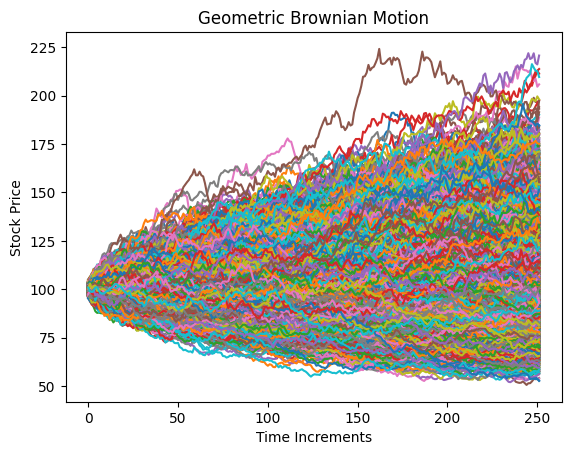

In [3]:
def gbm_paths(S, r, q, sigma, T, n_steps, n_paths):
    """Simulate stock price paths using geometric Brownian motion."""
    # Change in time for each step
    dt = T / n_steps
    # Generate array of random stock paths over time
    S_t_delta_t = S*np.exp(np.cumsum((r - q * sigma**2 / 2) * dt + sigma * np.sqrt(dt) * np.random.normal(size=(n_steps, n_paths)),axis=0))
    return S_t_delta_t

paths = gbm_paths(S0, r, q, sigma, T, n_steps, n_paths)
plt.plot(paths)
plt.xlabel("Time Increments")
plt.ylabel("Stock Price")
plt.title("Geometric Brownian Motion")


The plot above shows the different paths the stock, S0, can take.

# Terminal pricing distribution

The terminal price is the price of the stock at maturity. The option payoff depends only on the price of the stock at maturity, $S_T$, which explains how the monte carlo estimator derives the option price. The terminal pricing distribution is shown below.


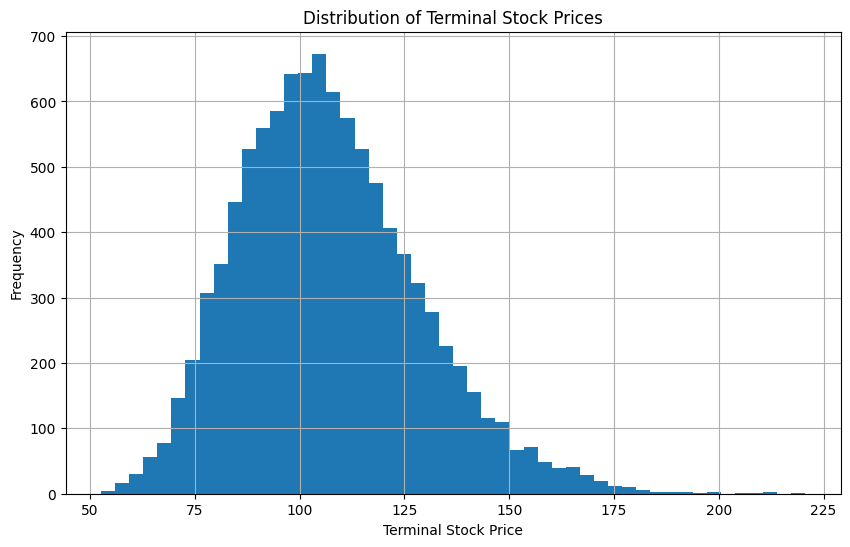

In [4]:
# The terminal stock prices are the last row of the paths array
ST = paths[-1]

# Plot the distribution of terminal stock prices
plt.figure(figsize=(10, 6))
plt.hist(ST, bins=50)
plt.title("Distribution of Terminal Stock Prices")
plt.xlabel("Terminal Stock Price")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Monte carlo pricing
The following cell gives the monte carlo price of a european stock option

In [5]:
def monte_carlo_call_price(ST, K, r, T):
    # Calculate the payoff of the call option at maturity
    payoffs = np.maximum(ST - K, 0)
    # Discount the average payoff back to present value
    price = np.exp(-r * T) * np.mean(payoffs)
    return price

mc_price = monte_carlo_call_price(ST, K, r, T)
mc_price

11.64175171862508

# Black-Scholes Benchmark

The following cell calculates the price of a call option using the Black-Scholes equation.


In [6]:
def black_scholes_call(S0, K, r, sigma, T):
    # Calculate d1 and d2 for the Black-Scholes formulas
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    # Calculate the call option price using the Black-Scholes formula
    call_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

bs_price = black_scholes_call(S0, K, r, sigma, T)
bs_price

10.450583572185565

# Compare Monte Carlo and Black-Scholes

In [7]:
# Calculate the absolute error between the Monte Carlo price and the Black-Scholes price
abs_error = abs(mc_price - bs_price)

# Print the results
print(f"Monte Carlo Price     : {mc_price:.6f}")
print(f"Black-Scholes Price   : {bs_price:.6f}")
print(f"Absolute Error        : {abs_error:.6f}")

Monte Carlo Price     : 11.641752
Black-Scholes Price   : 10.450584
Absolute Error        : 1.191168


The Monte Carlo estimate is similar to that of the Black-Scholes price. There is an absolute error of approximately 1.19. The Monte Carlo price is higher than the Black-Scholes price. This is due to error in the simulation. Increasing the number of simulations will make the prices converge. 

# Convergence Analysis 

As the number of simulations increases, the monte carlo estimate will converge to Black-Scholes. The Black-Scholes model calculates:

$$
V = e^{-rT} \,\mathbb{E}[\text{payoff}]
$$

The Monte Carlo estimate provides:

$$
\hat{V} = e^{-rT} \cdot \frac{1}{N} \sum_{i=1}^{N} \text{payoff}_i
$$

N is the number of simulations here. Due to the law of large numbers, $\frac{1}{N} \sum_{i=1}^{N} \text{payoff}_i$ becomes $\mathbb{E}[\text{payoff}]$ as N -> $\infty$

Hence, as the number of simulations increase, the Monte Carlo estimate will converge to Black-Scholes. This shown in the graph below, the Monte Carlo estimate is closest to the Black-Scholes price when there are 50000 simulations. 

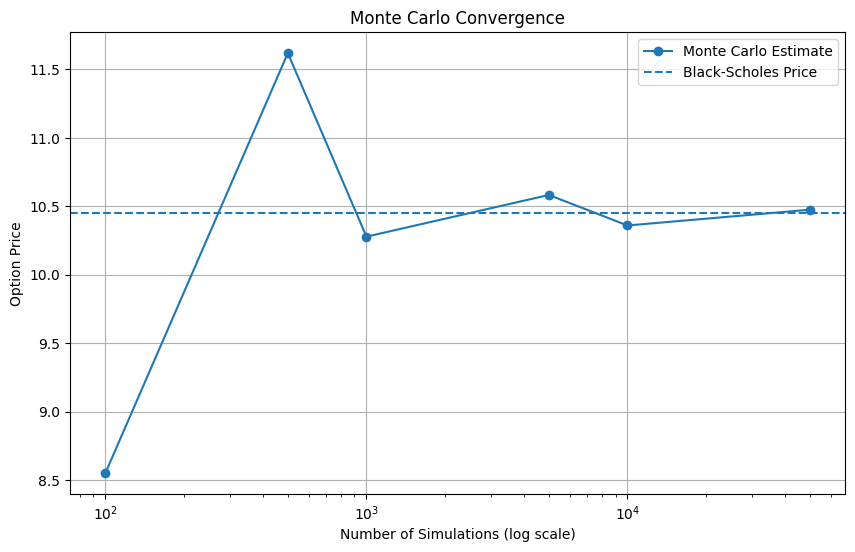

In [13]:
#Define a range of simulation sizes to analyze convergence
simulation_sizes = [100, 500, 1000, 5000, 10000, 50000]
# Initialize a list to store Monte Carlo estimates for each simulation size
mc_estimates = []

# Run Monte Carlo simulations for each specified simulation size and store the estimates
for n in simulation_sizes:
    Z = np.random.standard_normal(n)
    ST_n = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    # Calculate the payoff for the current simulation size
    payoffs_n = np.maximum(ST_n - K, 0)
    # Discount the average payoff back to present value to get the Monte Carlo estimate
    price_n = np.exp(-r * T) * np.mean(payoffs_n)
    mc_estimates.append(price_n)


# Plot the convergence of Monte Carlo estimates to the Black-Scholes price as the number of simulations increases
plt.figure(figsize=(10, 6))
plt.plot(simulation_sizes, mc_estimates, marker='o', label="Monte Carlo Estimate")
plt.axhline(bs_price, linestyle='--', label="Black-Scholes Price")
plt.xscale("log")
plt.title("Monte Carlo Convergence")
plt.xlabel("Number of Simulations (log scale)")
plt.ylabel("Option Price")
plt.legend()
plt.grid(True)
plt.show()